# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Clustering

## Load Data

In [2]:
df = pd.read_csv('./wine-clustering.csv')
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Data Exploration

In [3]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Based on the data exploration we can skip the feature engineering step and go straight to clustering.

## Clustering Algorithms

### K-Means

In [5]:
from sklearn.cluster import KMeans

#### Elbow Method

In [6]:
# Use elbow method to find the optimal number of clusters

sse = [] #SUM OF SQUARED ERROR

# Looping through k values from 1 to 10 and fitting the KMeans object with the data and appending the inertia_ value to the sse list
for k in range(1,11):
    # Create a KMeans instance with k clusters: model, k being the number of clusters for each iteration
    km = KMeans(n_clusters=k, random_state=69)
    # Fit model to samples
    km.fit(df)
    # Append the inertia to the list of inertias
    sse.append(km.inertia_)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

<Axes: >

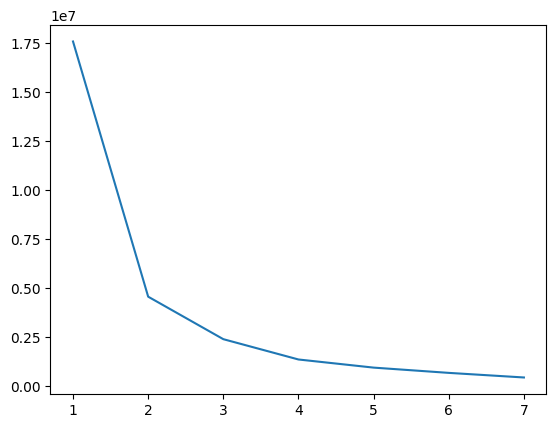

In [8]:
sns.lineplot(x=range(1, 8), y=sse)

From this we can conclude that the optimal number of clusters is 2 using elbow method.

#### Predictions K-Means

In [10]:
km_model = KMeans(n_clusters=2, random_state=69) # 2 clusters since the elbow is at 2 clusters
km_pred = km_model.fit_predict(df) # fit_predict() returns the cluster labels

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [12]:
px.scatter_3d(df, x='Alcohol', y='Magnesium', z='Flavanoids', color=km_pred) # 3D scatter plot of the clusters using plotly

The K-Means algorithm was able to cluster the data into 2 clusters pretty well even if there's still a few data that mixed up.

### DBSCAN

In [29]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN() # eps=0.5, min_samples=5 by default
dbscan_pred = dbscan_model.fit_predict(df) # fit_predict() returns the cluster labels

In [30]:
px.scatter_3d(df, x='Alcohol', y='Magnesium', z='Flavanoids', color=dbscan_pred)

DBSCAN could not cluster the data well because the data is too close together.

### Hierarchical Clustering (Agglomerative Clustering)

In [31]:
from sklearn.cluster import AgglomerativeClustering

ag_model = AgglomerativeClustering(n_clusters=2) # 2 clusters since the elbow is at 2 clusters
ag_pred = ag_model.fit_predict(df)

In [32]:
px.scatter_3d(df, x='Alcohol', y='Magnesium', z='Flavanoids', color=ag_pred)